# Phase 1 — Preprocessing

**N-Ticipate**, an n-gram + HMM autocomplete engine.

This notebook is the Phase 1 deliverable. The implementation lives in
`nticipate/preprocess.py`; here we run it, inspect what each stage does, and
produce the numbers the report needs: token counts before and after, a Zipf
plot, the type-token ratio, and the vocabulary coverage curve.

Two decisions shape everything below.

**Stopwords and punctuation stay.** Removing them is standard for text
*classification* and wrong for *language modelling*. `of the` is exactly the
bigram an autocomplete engine must predict, and a sentence-final `.` is a real
event a trigram model should learn.

**Counting is case-insensitive, output is truecased.** `the` and `The` are one
word statistically, so they are folded before counting. A separate truecase map
records how each word is normally written, so the app suggests `India`, not
`india` — without splitting the counts across two surface forms.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import matplotlib.pyplot as plt
from nticipate.preprocess import *
from nticipate.config import get

plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['figure.dpi'] = 110

## 1. Cleaning

`clean_text` normalises Unicode to NFC, drops URLs, emails and control
characters, folds curly quotes to ASCII, and squeezes whitespace.

NFC matters well beyond tidiness. Devanagari can encode the same grapheme
either precomposed or as a base plus a combining mark; without normalisation
the two forms count as different words in Phase 5.

In [2]:
examples = [
    '  The   quick\tbrown   fox  ',
    'Email me at a.b@test.co.in or see https://example.com/docs today',
    'She said \u201cdon\u2019t\u201d \u2014 twice',
]
for raw in examples:
    print(repr(raw))
    print('  ->', repr(clean_text(raw)))
    print()

'  The   quick\tbrown   fox  '
  -> 'The quick brown fox'

'Email me at a.b@test.co.in or see https://example.com/docs today'
  -> 'Email me at or see today'

'She said “don’t” — twice'
  -> 'She said "don\'t" - twice'



Note that `Hello, world!` keeps its comma and bang. That is the design
decision above, made visible:

In [3]:
print(clean_text('Hello, world!'))

Hello, world!


## 2. Sentence segmentation

NLTK's Punkt is used for English because it knows `Dr.` is not a sentence
boundary. Punkt has no Hindi model, so Devanagari text takes the regex path,
which splits on the danda `\u0964`. That is not a downgrade: the danda is an
unambiguous terminator with no abbreviation use, unlike the English full stop.

In [4]:
english = 'Dr. Smith went to Washington. He arrived on Monday! Did he stay?'
for s in segment_sentences(english):
    print(' *', s)

 * Dr. Smith went to Washington.
 * He arrived on Monday!
 * Did he stay?


In [5]:
hindi = '\u092f\u0939 \u090f\u0915 \u0935\u093e\u0915\u094d\u092f \u0939\u0948\u0964 \u092d\u093e\u0930\u0924 \u090f\u0915 \u092c\u0921\u093c\u093e \u0926\u0947\u0936 \u0939\u0948\u0964 \u092e\u0941\u091d\u0947 \u0939\u093f\u0902\u0926\u0940 \u092a\u0938\u0902\u0926 \u0939\u0948\u0964'
for s in segment_sentences(hindi):
    print(' *', s)

 * यह एक वाक्य है।
 * भारत एक बड़ा देश है।
 * मुझे हिंदी पसंद है।


## 3. Tokenisation

The Treebank tokenizer is primary; a regex fallback keeps the module usable
before the corpora are downloaded, and handles Devanagari.

The regex needed one non-obvious fix. A Devanagari vowel sign (matra) such as
`\u093e` is Unicode category `Mc` — a *mark*, not a letter — so both `\\w` and
`[^\\W\\d_]` reject it, and `\u092d\u093e\u0930\u0924` tokenised as three
pieces. The word pattern therefore matches letters *and* combining marks.

In [6]:
print(tokenize("I don't think it's Dr. Smith's car."))
print(tokenize('The price is 3.14 dollars, roughly.'))

['I', 'do', "n't", 'think', 'it', "'s", 'Dr.', 'Smith', "'s", 'car', '.']
['The', 'price', 'is', '3.14', 'dollars', ',', 'roughly', '.']


In [7]:
toks = tokenize('\u092d\u093e\u0930\u0924 \u090f\u0915 \u092c\u0921\u093c\u093e \u0926\u0947\u0936 \u0939\u0948\u0964')
print(toks)
print('danda is its own token:', '\u0964' in toks)

['भारत', 'एक', 'बड़ा', 'देश', 'है', '।']
danda is its own token: True


## 4. Load the corpus

Brown, via NLTK. Read through `.sents()`, never `.raw()` — Brown's raw form is
POS-tagged (`The/at Fulton/np-tl`), so raw text would train the language model
on tag-suffixed pseudo-words. `.sents()` also supplies the corpus's own gold
sentence segmentation and tokenisation, which beats re-deriving it with Punkt.

In [8]:
sentences = load_corpus_sentences('brown')
print(f'{len(sentences):,} sentences')
print(sentences[0])

57,340 sentences
['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', "Atlanta's", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', "''", 'that', 'any', 'irregularities', 'took', 'place', '.']


In [9]:
before = corpus_stats(sentences)
for k, v in before.items():
    print(f'{k:>22}: {v:,.4f}' if isinstance(v, float) else f'{k:>22}: {v:,}')

             sentences: 57,340
                tokens: 1,161,192
                 types: 56,057
      type_token_ratio: 0.0483
                 hapax: 25,559
           hapax_ratio: 0.4559
  mean_sentence_length: 20.2510


## 5. Vocabulary and `<UNK>`

Tokens below `preprocessing.min_token_freq` are replaced by `<UNK>`.

This is not a size optimisation. Without an `<UNK>` class, an unseen word gets
probability zero, and held-out perplexity in Phase 2 becomes infinite. The
hapax ratio above says how large that problem is: nearly half of all *types*
occur exactly once.

The vocabulary is built from the **training split only**. Building it from the
whole corpus would leak test-set vocabulary into the model and flatter the
Phase 2 numbers.

In [10]:
corpus = preprocess_sentences(sentences)
print(f'vocabulary        : {len(corpus.vocab):,} types')
print(f'train / dev / test: {len(corpus.train):,} / {len(corpus.dev):,} / {len(corpus.test):,}')
print(f'min_token_freq    : {get("preprocessing.min_token_freq")}')

vocabulary        : 24,634 types
train / dev / test: 45,610 / 5,701 / 5,702
min_token_freq    : 2


In [11]:
after = corpus_stats(corpus.train)

print(f'{"metric":>22}  {"raw corpus":>14}  {"after preprocessing":>20}')
print('-' * 60)
for key in ['sentences', 'tokens', 'types', 'type_token_ratio', 'hapax', 'mean_sentence_length']:
    a, b = before[key], after[key]
    fmt = (lambda x: f'{x:,.4f}') if isinstance(a, float) else (lambda x: f'{x:,}')
    print(f'{key:>22}  {fmt(a):>14}  {fmt(b):>20}')

                metric      raw corpus   after preprocessing
------------------------------------------------------------
             sentences          57,340                45,610
                tokens       1,161,192               927,438
                 types          56,057                24,635
      type_token_ratio          0.0483                0.0266
                 hapax          25,559                     0
  mean_sentence_length         20.2510               20.3341


`hapax` drops to zero after preprocessing, by construction: every token that
occurred once is now `<UNK>`. `types` falls by roughly half for the same
reason, while `tokens` barely moves — which is the whole argument for the
`<UNK>` class. We discard most of the vocabulary and almost none of the text.

In [12]:
oov = oov_rate(corpus.dev, corpus.vocab)
print(f'OOV rate on the dev split: {oov:.2%}')
print('\nMost frequent tokens in the training split:')
for token, count in frequency_table(corpus.train, 15):
    print(f'  {token:>8}  {count:>7,}')

OOV rate on the dev split: 3.68%

Most frequent tokens in the training split:


       the   55,945
         ,   46,526
         .   39,460
        of   29,151
       and   22,993
        to   20,914
     <UNK>   20,383
         a   18,507
        in   17,020
      that    8,494
        is    8,136
       was    7,769
        he    7,623
       for    7,587
        ``    7,078


The top of that list is punctuation and stopwords, which is precisely why
neither was removed. `<UNK>` also appears near the top — it is a frequent
*class*, even though each of its members is rare.

## 6. Zipf's law

Word frequency against frequency rank, log-log. A straight line means the
corpus obeys Zipf's law, which is what justifies both the `<UNK>` cutoff and
the Phase 2 pruning: the tail is enormous and carries very little probability
mass.

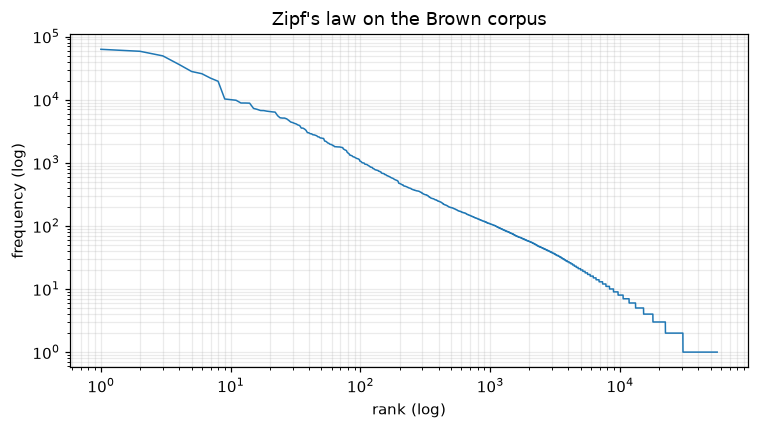

In [13]:
ranks, freqs = zipf_points(sentences)

fig, ax = plt.subplots()
ax.loglog(ranks, freqs, linewidth=1)
ax.set_xlabel('rank (log)')
ax.set_ylabel('frequency (log)')
ax.set_title("Zipf's law on the Brown corpus")
ax.grid(True, which='both', alpha=0.25)
plt.tight_layout()
plt.show()

## 7. Vocabulary coverage

How much of the running text the top-N most frequent types account for. This
is the evidence behind `preprocessing.max_vocab_size`, and behind the Phase 2
pruning that shrinks the shipped model.

  top    100 types  ->  55.32% of tokens
  top    500 types  ->  68.73% of tokens
  top  1,000 types  ->  74.88% of tokens
  top  2,000 types  ->  81.40% of tokens
  top  5,000 types  ->  89.94% of tokens
  top 10,000 types  ->  95.16% of tokens
  top 20,000 types  ->  99.00% of tokens
  top 24,635 types  ->  100.00% of tokens


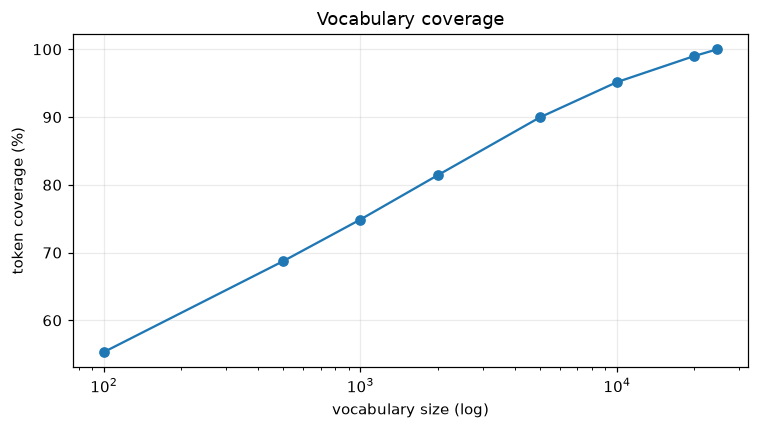

In [14]:
curve = coverage_curve(corpus.train)
for n, pct in curve:
    print(f'  top {n:>6,} types  ->  {pct:6.2%} of tokens')

fig, ax = plt.subplots()
ax.plot([n for n, _ in curve], [p * 100 for _, p in curve], marker='o')
ax.set_xscale('log')
ax.set_xlabel('vocabulary size (log)')
ax.set_ylabel('token coverage (%)')
ax.set_title('Vocabulary coverage')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## 8. Truecasing

The map records, for each lowercased word, the surface form it usually takes.

Sentence-initial tokens are **skipped** when counting. Their capital is a
typographic convention, not evidence about the word — counting them would let
every sentence-initial `The` argue that *the* is normally capitalised. Words
seen only sentence-initially therefore get no entry and stay lowercase, which
is the honest answer when the corpus carries no evidence either way.

In [15]:
for word in ['india', 'the', 'monday', 'however', 'american', 'god', 'i']:
    print(f'  {word:>10}  ->  {truecase_word(word, corpus.truecase)}')

       india  ->  India
         the  ->  the
      monday  ->  Monday
     however  ->  however
    american  ->  American
         god  ->  God
           i  ->  I


In [16]:
demo = 'india is a large country and monday is a busy day'
tokens = tokenize(demo)
print('raw      :', ' '.join(tokens))
print('truecased:', ' '.join(apply_truecase(tokens, corpus.truecase, capitalize_first=True)))

raw      : india is a large country and monday is a busy day
truecased: India is a large country and Monday is a busy day


## 9. Padding and splitting

`pad_sentence` wraps a sentence in `n-1` BOS markers and one EOS marker.
`n-1` of them because a trigram model predicting the *first* real word still
needs two tokens of left context. The single EOS is what teaches the model
where sentences end — without it, generated text runs on forever.

In [17]:
sent = ['the', 'cat', 'sat']
for n in (1, 2, 3):
    print(f'n={n}: {pad_sentence(sent, n)}')

n=1: ['the', 'cat', 'sat', '</s>']
n=2: ['<s>', 'the', 'cat', 'sat', '</s>']
n=3: ['<s>', '<s>', 'the', 'cat', 'sat', '</s>']


Splitting is done at sentence level with a fixed seed, so runs are
reproducible and no single document's vocabulary lands entirely in the test
set.

In [18]:
print(f'train {len(corpus.train):,}  dev {len(corpus.dev):,}  test {len(corpus.test):,}')
print(f'seed  {get("preprocessing.split.seed")}')

train 45,610  dev 5,701  test 5,702
seed  42


## 10. Save for Phase 2

In [19]:
path = corpus.save(default_processed_path('brown.json'))
print(f'saved {path} ({path.stat().st_size / 1e6:.1f} MB)')

saved C:\Sudev D\Projects\N-Ticipate\data\processed\brown.json (11.8 MB)


## Summary

| Result | Value |
| --- | --- |
| Sentences | 57,340 raw &rarr; 45,610 train |
| Tokens | 1,161,192 raw &rarr; 927,438 train |
| Types | 56,057 raw &rarr; 24,634 in vocabulary |
| Type-token ratio | 0.048 raw &rarr; 0.027 after `<UNK>` |
| Hapax types | 25,559 (45.6% of all types) |
| Dev-split OOV rate | ~3.7% |
| Coverage by top 5,000 types | ~90% of tokens |

The headline finding is the gap between the last two rows of that table: 5,000
types cover ninety percent of the running text, while 25,559 types appear
exactly once each. That asymmetry is what makes a small, fast, shippable model
possible at all — and it is the direct justification for the `<UNK>` cutoff
here and the n-gram pruning in Phase 2.

Next: **Phase 2 — n-gram language model**, which consumes `data/processed/brown.json`.